In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models

import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
# onnxファイルを作成する関数
def model_to_onnx(model, output_file, input_shape = (1, 3, 224, 224)):
  model.eval()
  input_tensor = torch.randn(input_shape).to('cpu')
  input_names = ['input']
  output_names = ['output']
  torch.onnx.export(model, input_tensor, output_file, verbose = False, input_names = input_names, output_names = output_names)
  return output_file

In [3]:
# モデル読み込み
pt_model_path = "../dense_CIFAR100.pt"
model = models.resnet18(weights = "IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 100)  # CIFAR-100 にあわせて出力層変更
model.load_state_dict(torch.load(pt_model_path))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# 訓練データセット作成
transform = transforms.Compose([transforms.Resize(224),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])   # 正規化したほうがいいらしい

trainset = torchvision.datasets.CIFAR100(root = "../data", train = True, download = True, transform = transform)
trainloader = DataLoader(trainset, batch_size = 400, shuffle = True)

In [5]:
# 枝刈り前のTVを見てみる

def Omega(delta):
    """
    4階テンソルdeltaの各次元に沿った差分を計算し、
    その絶対値の総和を返す。
    """
    h = 1.0  # Dのパラメータ

    # 4つの次元それぞれに対して差分（勾配）を計算

    # dim=0 (出力チャネル方向の差分)
    diff_dim0 = delta[1:, :, :, :] - delta[:-1, :, :, :]

    # dim=1 (入力チャネル方向の差分)
    diff_dim1 = delta[:, 1:, :, :] - delta[:, :-1, :, :]

    # dim=2 (縦方向の差分)
    # 1行目から最後までと、0行目から最後の一つ手前までの差
    diff_dim2 = delta[:, :, 1:, :] - delta[:, :, :-1, :]

    # dim=3 (横方向の差分)
    # 1列目から最後までと、0列目から最後の一つ手前までの差
    diff_dim3 = delta[:, :, :, 1:] - delta[:, :, :, :-1]

    # 全ての差分の絶対値の総和を計算
    # これがD@deltaに相当する操作のL1ノルムになる
    constrain = torch.sum(torch.abs(diff_dim0)) + torch.sum(torch.abs(diff_dim1)) + torch.sum(torch.abs(diff_dim2)) + torch.sum(torch.abs(diff_dim3))

    return constrain / h

layer_tvs = {}
layer_relative_tvs = {}
conv_layer_names = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        w_tensor = module.weight.detach().clone().to(device)
        tv = Omega(w_tensor).item()
        ave_tv = tv/(w_tensor).numel()
        relative_tv = tv / torch.sum(torch.abs(w_tensor)).item()
        layer_tvs[name] = tv
        layer_relative_tvs[name] = relative_tv
        conv_layer_names.append(name)
        print(f"{name}：TV={tv:.4f}     ave_TV={ave_tv:.4f}     relative_TV={relative_tv:.4f}")

conv1：TV=2785.2295     ave_TV=0.2960     relative_TV=3.8856
layer1.0.conv1：TV=5374.9766     ave_TV=0.1458     relative_TV=4.5978
layer1.0.conv2：TV=5114.5527     ave_TV=0.1387     relative_TV=4.3287
layer1.1.conv1：TV=5668.0166     ave_TV=0.1538     relative_TV=4.4810
layer1.1.conv2：TV=5086.6060     ave_TV=0.1380     relative_TV=4.3702
layer2.0.conv1：TV=9617.4121     ave_TV=0.1304     relative_TV=4.4250
layer2.0.conv2：TV=15764.6738     ave_TV=0.1069     relative_TV=4.4388
layer2.0.downsample.0：TV=1078.0977     ave_TV=0.1316     relative_TV=2.9595
layer2.1.conv1：TV=16097.3955     ave_TV=0.1092     relative_TV=4.4760
layer2.1.conv2：TV=14066.4082     ave_TV=0.0954     relative_TV=4.2584
layer3.0.conv1：TV=24614.0742     ave_TV=0.0835     relative_TV=3.9532
layer3.0.conv2：TV=45880.5859     ave_TV=0.0778     relative_TV=4.1893
layer3.0.downsample.0：TV=2272.0547     ave_TV=0.0693     relative_TV=2.8928
layer3.1.conv1：TV=41812.7227     ave_TV=0.0709     relative_TV=4.2032
layer3.1.conv2：TV=37850

In [6]:
# すべての畳み込み層を枝刈り対象に
parameters_to_prune = [
    (module, "weight") for module in model.modules() if isinstance(module, torch.nn.Conv2d)
]

# 大域的・非構造・強度枝刈り
cut_rate = 0.99
prune.global_unstructured(
    parameters_to_prune,
    pruning_method = prune.L1Unstructured,
    amount = cut_rate,
)

In [7]:
# この後に非構造枝刈りを行うのでマスクとモデルのサイズが異なるのを防ぐために永続化（マスクと重みを掛ける）
for module in model.modules():
  if isinstance(module, torch.nn.Conv2d):
    prune.remove(module, "weight")

In [8]:
# ゼロ比率を表示
zero_ratings = {}
for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    zero_ratings[name] = float(torch.sum(module.weight == 0)) / float(module.weight.nelement())
    print(f"{name} Zero-Ratio: {100.0 * zero_ratings[name]:.2f}%")

conv1 Zero-Ratio: 64.82%
layer1.0.conv1 Zero-Ratio: 87.62%
layer1.0.conv2 Zero-Ratio: 88.15%
layer1.1.conv1 Zero-Ratio: 87.14%
layer1.1.conv2 Zero-Ratio: 88.86%
layer2.0.conv1 Zero-Ratio: 90.15%
layer2.0.conv2 Zero-Ratio: 94.50%
layer2.0.downsample.0 Zero-Ratio: 80.90%
layer2.1.conv1 Zero-Ratio: 94.41%
layer2.1.conv2 Zero-Ratio: 96.16%
layer3.0.conv1 Zero-Ratio: 96.60%
layer3.0.conv2 Zero-Ratio: 98.03%
layer3.0.downsample.0 Zero-Ratio: 94.85%
layer3.1.conv1 Zero-Ratio: 98.75%
layer3.1.conv2 Zero-Ratio: 99.19%
layer4.0.conv1 Zero-Ratio: 99.44%
layer4.0.conv2 Zero-Ratio: 99.77%
layer4.0.downsample.0 Zero-Ratio: 95.02%
layer4.1.conv1 Zero-Ratio: 99.82%
layer4.1.conv2 Zero-Ratio: 99.94%


In [9]:
# 構造的かつ非構造枝刈りしたときのゼロ比率を表示
all_conv_params = 0
all_conv_zeros = 0

for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    print(f"{name} Zero-Ratio: {100.0 * float(torch.sum(module.weight == 0)) / float(module.weight.nelement()):.4f}%")
    weight_after_pruning = module.weight
    num_zeros = (weight_after_pruning == 0).sum().item()
    total_params = weight_after_pruning.numel()
    all_conv_params += total_params
    all_conv_zeros += num_zeros

sparsity = 100. * all_conv_zeros / all_conv_params if all_conv_params > 0 else 0
print(f"全畳み込み層の0率：{sparsity:.4f}%")

print(model)

conv1 Zero-Ratio: 64.8172%
layer1.0.conv1 Zero-Ratio: 87.6221%
layer1.0.conv2 Zero-Ratio: 88.1538%
layer1.1.conv1 Zero-Ratio: 87.1365%
layer1.1.conv2 Zero-Ratio: 88.8618%
layer2.0.conv1 Zero-Ratio: 90.1503%
layer2.0.conv2 Zero-Ratio: 94.5001%
layer2.0.downsample.0 Zero-Ratio: 80.8960%
layer2.1.conv1 Zero-Ratio: 94.4092%
layer2.1.conv2 Zero-Ratio: 96.1616%
layer3.0.conv1 Zero-Ratio: 96.6017%
layer3.0.conv2 Zero-Ratio: 98.0253%
layer3.0.downsample.0 Zero-Ratio: 94.8517%
layer3.1.conv1 Zero-Ratio: 98.7466%
layer3.1.conv2 Zero-Ratio: 99.1938%
layer4.0.conv1 Zero-Ratio: 99.4393%
layer4.0.conv2 Zero-Ratio: 99.7653%
layer4.0.downsample.0 Zero-Ratio: 95.0218%
layer4.1.conv1 Zero-Ratio: 99.8240%
layer4.1.conv2 Zero-Ratio: 99.9404%
全畳み込み層の0率：99.0000%
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=

In [10]:
# 強度枝刈り後のTVを見る

layer_tvs = {}
layer_relative_tvs = {}
conv_layer_names = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        w_tensor = module.weight.detach().clone().to(device)
        tv = Omega(w_tensor).item()
        ave_tv = tv/(w_tensor).numel()
        relative_tv = tv / torch.sum(torch.abs(w_tensor)).item()
        layer_tvs[name] = tv
        layer_relative_tvs[name] = relative_tv
        conv_layer_names.append(name)
        print(f"{name}：TV={tv:.4f}     ave_TV={ave_tv:.4f}     relative_TV={relative_tv:.4f}")

conv1：TV=2494.2939     ave_TV=0.2651     relative_TV=4.2403
layer1.0.conv1：TV=3069.7222     ave_TV=0.0833     relative_TV=5.7450
layer1.0.conv2：TV=2487.6179     ave_TV=0.0675     relative_TV=5.7078
layer1.1.conv1：TV=2919.7429     ave_TV=0.0792     relative_TV=5.7477
layer1.1.conv2：TV=2309.9907     ave_TV=0.0627     relative_TV=5.7262
layer2.0.conv1：TV=4115.4434     ave_TV=0.0558     relative_TV=5.7890
layer2.0.conv2：TV=4831.2139     ave_TV=0.0328     relative_TV=6.2078
layer2.0.downsample.0：TV=716.8086     ave_TV=0.0875     relative_TV=3.6069
layer2.1.conv1：TV=4787.6030     ave_TV=0.0325     relative_TV=6.1021
layer2.1.conv2：TV=3036.7815     ave_TV=0.0206     relative_TV=6.1233
layer3.0.conv1：TV=4983.8555     ave_TV=0.0169     relative_TV=5.4458
layer3.0.conv2：TV=6245.0059     ave_TV=0.0106     relative_TV=6.0579
layer3.0.downsample.0：TV=604.2323     ave_TV=0.0184     relative_TV=3.8845
layer3.1.conv1：TV=3876.0864     ave_TV=0.0066     relative_TV=6.0840
layer3.1.conv2：TV=2435.9810    

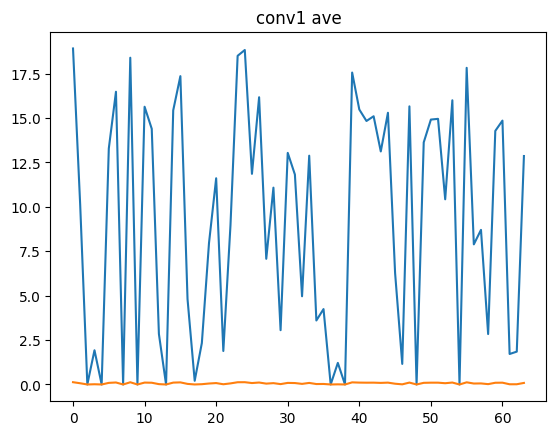

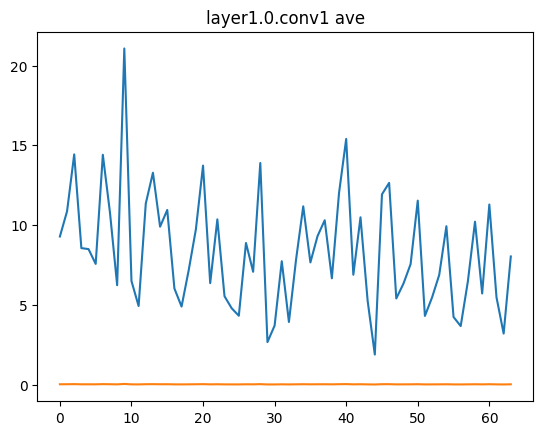

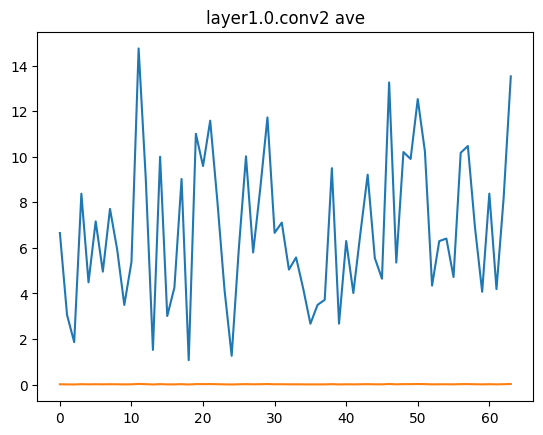

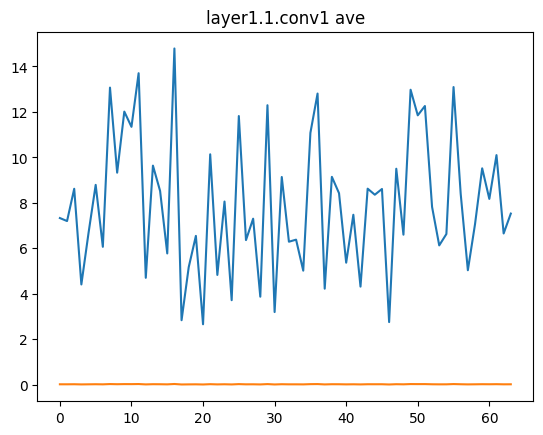

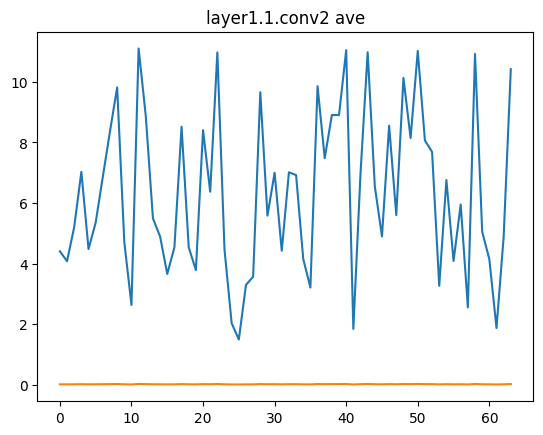

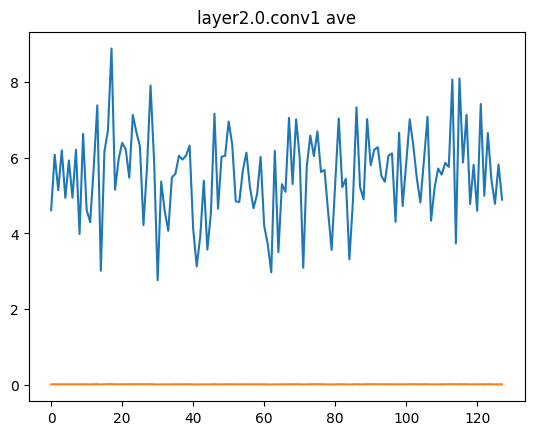

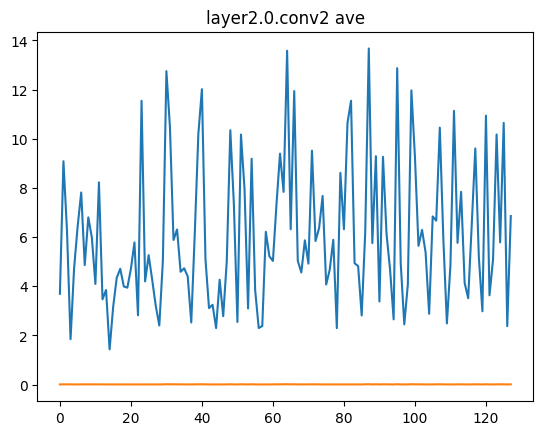

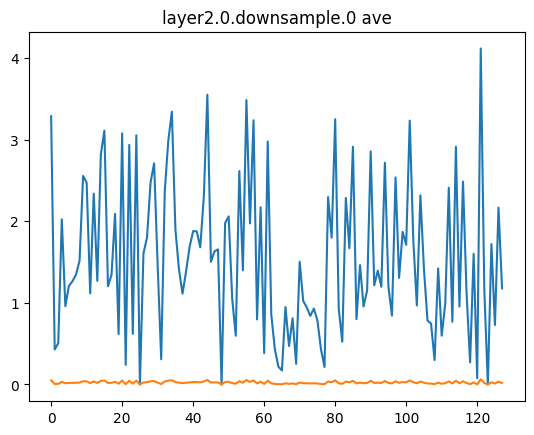

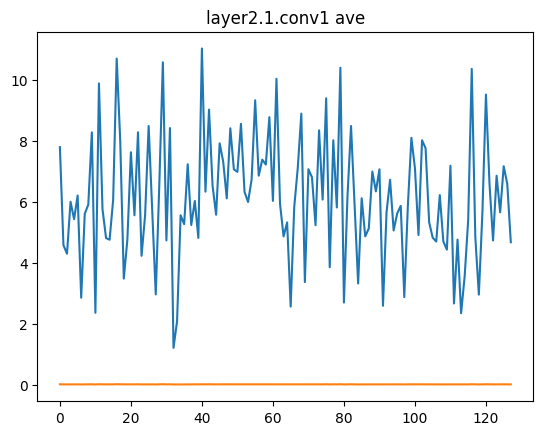

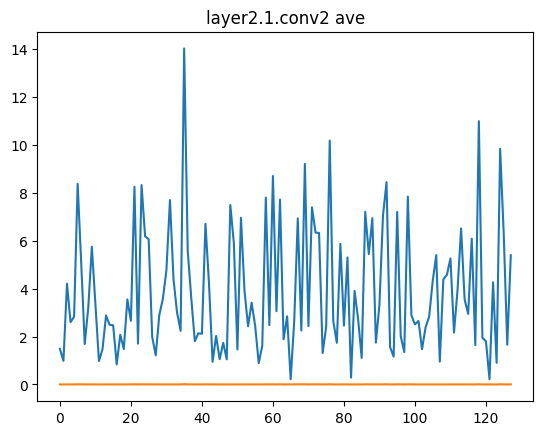

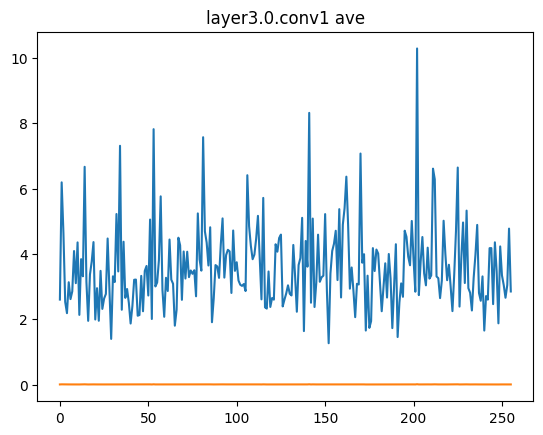

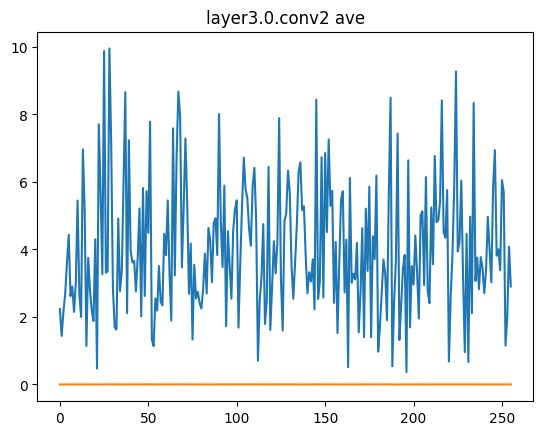

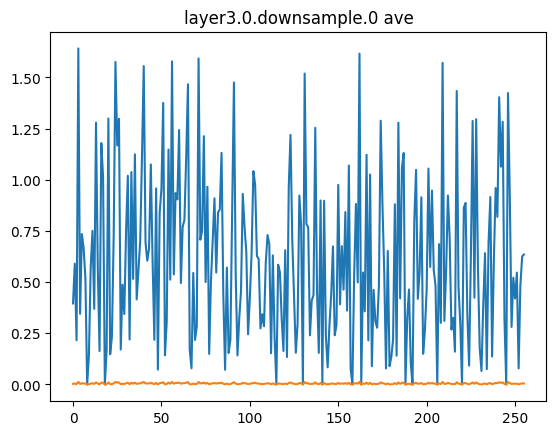

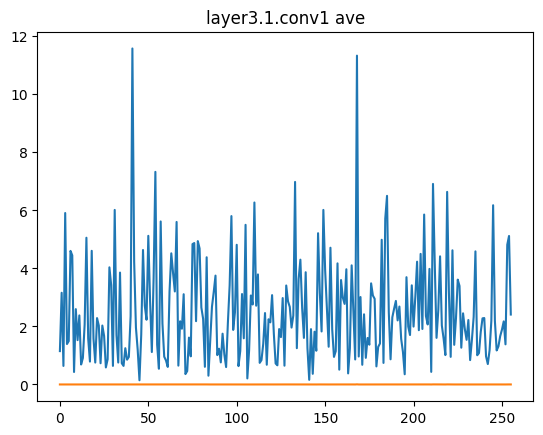

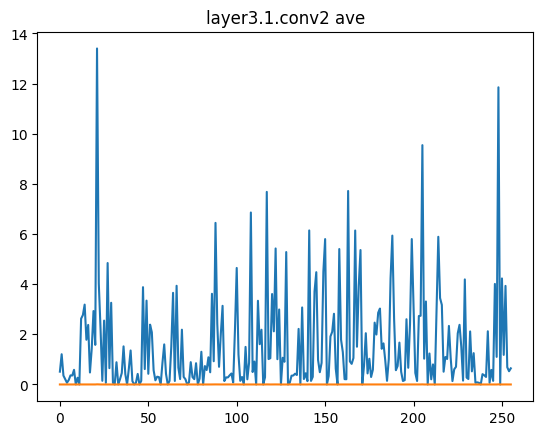

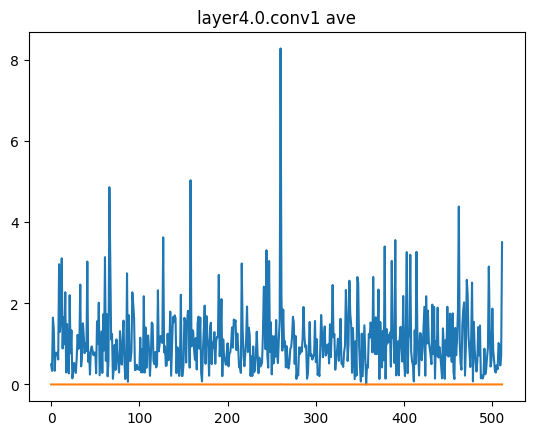

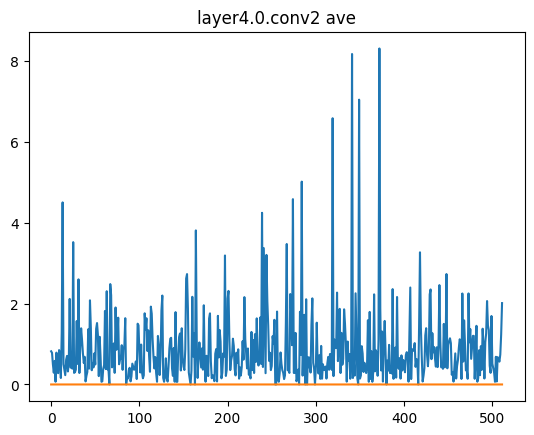

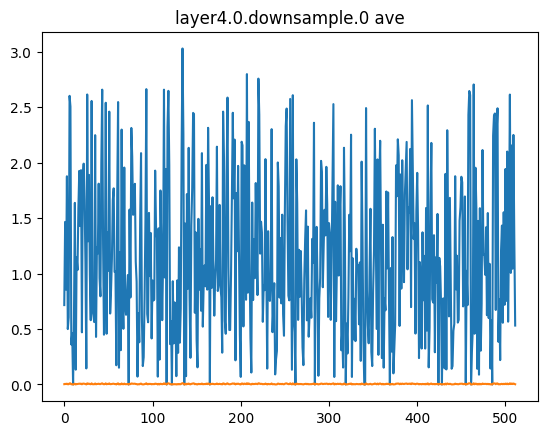

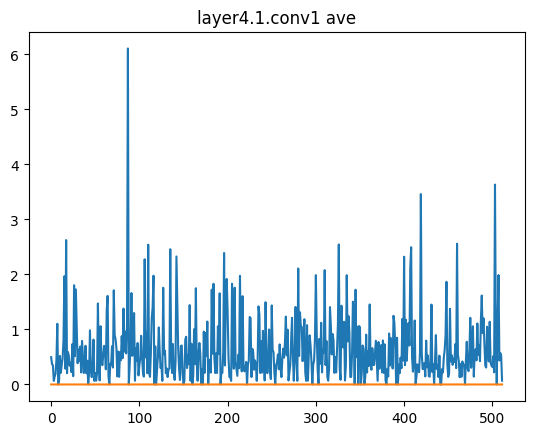

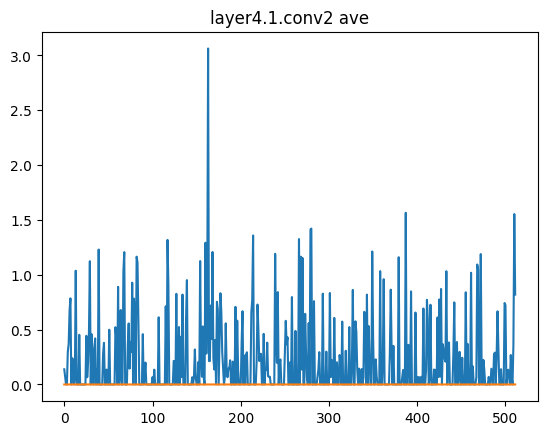

In [11]:
# フィルターごとの重み合計や平均を見る
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        # 重みテンソルを取得 (out_channels, in_channels, h, w)
        weight = module.weight.detach()
        
        # フィルター（out_channels次元）ごとに、絶対値の合計を計算
        # dim=(1,2,3) は in_channels, height, width の次元を潰すという意味
        filter_sum = torch.sum(torch.abs(weight), dim=(1, 2, 3))
        filter_ave = filter_sum / (weight.size()[1]*weight.size()[2]*weight.size()[3])

        plt.plot(filter_sum)
        #plt.ylim(-0.1, 0.2)
        plt.title(name+" sum")
        #plt.show()
        plt.plot(filter_ave)
        plt.title(name+" ave")
        #plt.ylim(-0, 0.01)
        plt.show()

In [12]:
import torch_pruning as tp
#print(tp.__version__)
#print(tp.__file__)

# 準備ができたモデルをGPU/CPUに送る
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


####### ADMM後のモデルを用いて枝刈りターゲットを特定

# 枝刈りしたいモジュール名と、その中で削除するチャネルのインデックスを保存する辞書
pruning_targets_by_name = {}

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        # 重みテンソルを取得 (out_channels, in_channels, h, w)
        weight = module.weight.detach()
        
        # フィルター（out_channels次元）ごとに、絶対値の合計を計算
        # dim=(1,2,3) は in_channels, height, width の次元を潰すという意味
        filter_sum = torch.sum(torch.abs(weight), dim=(1, 2, 3))
        filter_ave = filter_sum / (weight.size()[1]*weight.size()[2]*weight.size()[3])
        
        # 合計が0のフィルター（＝全ての重みが0のフィルター）のインデックスを見つける
        indices_to_prune = torch.where((filter_sum <= 0.5) & (filter_ave<=0.005))[0].tolist()   #  filter_sum == 0
        
        # 刈るべきフィルターが1つでもあれば、辞書に記録
        if indices_to_prune:
            pruning_targets_by_name[name] = indices_to_prune
            print(f"レイヤー '{name}': {len(indices_to_prune)}個のフィルターを枝刈り対象として特定。")

#######

# 非構造枝刈りのためのmaskを作るためにADMM後のモデルに対し非構造枝刈りを行う
# 依存関係グラフを構築するためのダミー入力
# 値はランダムでOK。形状が正しいことが重要。
example_inputs = torch.randn(1, 3, 224, 224).to(device)

# ★★★ ここからが、より堅牢なワークフロー ★★★

# 1. 依存関係グラフを構築 (これは変更なし)
DG = tp.DependencyGraph()
DG.build_dependency(model, example_inputs=example_inputs)

# 2. 枝刈りグループのリストを作成する
pruning_groups = []
for name, indices in pruning_targets_by_name.items():
    # ターゲットのモジュールを取得
    module_to_prune = model.get_submodule(name)
    
    # 3. DG.get_pruning_groupを使って、依存関係を明示的に解決させる
    #    このグループには、conv1だけでなく、bn1なども自動的に含まれる
    group = DG.get_pruning_group(
        module=module_to_prune, 
        pruning_fn=tp.function.prune_conv_out_channels,  
        idxs=indices
    )
    pruning_groups.append(group)
    print(f"レイヤー '{name}' の枝刈りグループを作成: {group}")

# 4. グループを一つずつ実行する
for group in pruning_groups:
    # 念のため、グループが有効かチェック
    if DG.check_pruning_group(group):
        group.prune()

# maskをつくる
threshold = 0

masks = {}

for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        # 現在の重みを取得
        weights = module.weight.detach()
        
        # 閾値に基づいてマスクを作成 (絶対値が0でない要素が1、0であれば0)
        masks[name] = (torch.abs(weights) != threshold).float().to(weights.device)

# maskをかける
for name, module in model.named_modules(): 
    if name in masks:
        prune.CustomFromMask.apply(module, "weight", mask=masks[name])


レイヤー 'conv1': 10個のフィルターを枝刈り対象として特定。
レイヤー 'layer2.0.downsample.0': 12個のフィルターを枝刈り対象として特定。
レイヤー 'layer2.1.conv2': 3個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.0.conv2': 2個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.0.downsample.0': 113個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.1.conv1': 11個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.1.conv2': 103個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.0.conv1': 122個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.0.conv2': 217個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.0.downsample.0': 105個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.1.conv1': 270個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.1.conv2': 416個のフィルターを枝刈り対象として特定。
レイヤー 'conv1' の枝刈りグループを作成: 
--------------------------------
          Pruning Group
--------------------------------
[0] prune_out_channels on conv1 (Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)) => prune_out_channels on conv1 (Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)), len(idxs)=10
[1] prune_out_channels on conv1 (Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(

In [13]:
# 構造的かつ非構造枝刈りしたときのゼロ比率を表示
all_conv_params = 0
all_conv_zeros = 0

for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    print(f"{name} Zero-Ratio: {100.0 * float(torch.sum(module.weight == 0)) / float(module.weight.nelement()):.4f}%")
    weight_after_pruning = module.weight
    num_zeros = (weight_after_pruning == 0).sum().item()
    total_params = weight_after_pruning.numel()
    all_conv_params += total_params
    all_conv_zeros += num_zeros

sparsity = 100. * all_conv_zeros / all_conv_params if all_conv_params > 0 else 0
print(f"全畳み込み層の0率：{sparsity:.4f}%")

print(model)

conv1 Zero-Ratio: 58.3396%
layer1.0.conv1 Zero-Ratio: 85.4360%
layer1.0.conv2 Zero-Ratio: 87.9469%
layer1.1.conv1 Zero-Ratio: 86.6609%
layer1.1.conv2 Zero-Ratio: 89.1461%
layer2.0.conv1 Zero-Ratio: 90.1058%
layer2.0.conv2 Zero-Ratio: 94.6188%
layer2.0.downsample.0 Zero-Ratio: 79.3047%
layer2.1.conv1 Zero-Ratio: 94.5168%
layer2.1.conv2 Zero-Ratio: 96.3199%
layer3.0.conv1 Zero-Ratio: 96.5773%
layer3.0.conv2 Zero-Ratio: 98.0836%
layer3.0.downsample.0 Zero-Ratio: 94.7616%
layer3.1.conv1 Zero-Ratio: 98.8394%
layer3.1.conv2 Zero-Ratio: 99.1856%
layer4.0.conv1 Zero-Ratio: 99.3443%
layer4.0.conv2 Zero-Ratio: 99.6008%
layer4.0.downsample.0 Zero-Ratio: 95.0763%
layer4.1.conv1 Zero-Ratio: 99.6057%
layer4.1.conv2 Zero-Ratio: 99.8920%
全畳み込み層の0率：97.9977%
ResNet(
  (conv1): Conv2d(3, 54, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(54, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=

In [14]:
# 再訓練
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)   #lr = 0.001で損失0.02とか
num_epochs = 20 #15
epoch_loss_list = []
# CosineAnnealingLRを定義
# T_max: 学習率が半周期で最小値になるまでのエポック数。通常、総エポック数を指定。
# eta_min: 最小学習率。
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0)

for epoch in range(num_epochs):
  model.train()
  model = model.to(device)
  total_loss = 0.0
  num_train = 0
  for inputs, labels in trainloader:
    inputs, labels = inputs.to(device), labels.to(device)   # データ代入

    # 重み更新のための手順
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # 損失を記録
    total_loss += loss.item()*labels.size(0)
    num_train+=labels.size(0)

  # 出力と記録
  epoch_loss_list.append(total_loss/num_train)
  current_lr = optimizer.param_groups[0]['lr']
  print(f'Epoch[{epoch+1}/{num_epochs}], Loss: {epoch_loss_list[epoch]:.4f}, LR: {current_lr:.8f}')


  # 次のエポックへの準備
  if epoch >= 1:
    if np.abs(epoch_loss_list[epoch]-epoch_loss_list[epoch-1]) < 0.001:
      break
  scheduler.step()

Epoch[1/20], Loss: 3.9253, LR: 0.00100000
Epoch[2/20], Loss: 2.9713, LR: 0.00099384
Epoch[3/20], Loss: 2.4675, LR: 0.00097553
Epoch[4/20], Loss: 2.1711, LR: 0.00094550
Epoch[5/20], Loss: 1.9769, LR: 0.00090451
Epoch[6/20], Loss: 1.8301, LR: 0.00085355
Epoch[7/20], Loss: 1.7183, LR: 0.00079389
Epoch[8/20], Loss: 1.6306, LR: 0.00072700
Epoch[9/20], Loss: 1.5561, LR: 0.00065451
Epoch[10/20], Loss: 1.4881, LR: 0.00057822
Epoch[11/20], Loss: 1.4324, LR: 0.00050000
Epoch[12/20], Loss: 1.3839, LR: 0.00042178
Epoch[13/20], Loss: 1.3394, LR: 0.00034549
Epoch[14/20], Loss: 1.3034, LR: 0.00027300
Epoch[15/20], Loss: 1.2747, LR: 0.00020611
Epoch[16/20], Loss: 1.2502, LR: 0.00014645
Epoch[17/20], Loss: 1.2313, LR: 0.00009549
Epoch[18/20], Loss: 1.2157, LR: 0.00005450
Epoch[19/20], Loss: 1.2076, LR: 0.00002447
Epoch[20/20], Loss: 1.2008, LR: 0.00000616


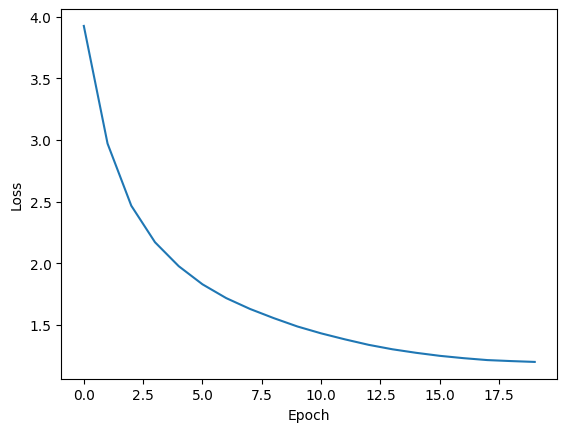

In [15]:
# 損失グラフ作成
plt.plot(epoch_loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [16]:
# 永続化（マスクと重みを掛ける）
for module in model.modules():
  if isinstance(module, torch.nn.Conv2d):
    prune.remove(module, "weight")

In [17]:
# 構造的かつ非構造枝刈りしたときのゼロ比率を表示
all_conv_params = 0
all_conv_zeros = 0

for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    print(f"{name} Zero-Ratio: {100.0 * float(torch.sum(module.weight == 0)) / float(module.weight.nelement()):.4f}%")
    weight_after_pruning = module.weight
    num_zeros = (weight_after_pruning == 0).sum().item()
    total_params = weight_after_pruning.numel()
    all_conv_params += total_params
    all_conv_zeros += num_zeros

sparsity = 100. * all_conv_zeros / all_conv_params if all_conv_params > 0 else 0
print(f"全畳み込み層の0率：{sparsity:.4f}%")

print(model)

conv1 Zero-Ratio: 58.3396%
layer1.0.conv1 Zero-Ratio: 85.4360%
layer1.0.conv2 Zero-Ratio: 87.9469%
layer1.1.conv1 Zero-Ratio: 86.6609%
layer1.1.conv2 Zero-Ratio: 89.1461%
layer2.0.conv1 Zero-Ratio: 90.1058%
layer2.0.conv2 Zero-Ratio: 94.6188%
layer2.0.downsample.0 Zero-Ratio: 79.3047%
layer2.1.conv1 Zero-Ratio: 94.5168%
layer2.1.conv2 Zero-Ratio: 96.3199%
layer3.0.conv1 Zero-Ratio: 96.5773%
layer3.0.conv2 Zero-Ratio: 98.0836%
layer3.0.downsample.0 Zero-Ratio: 94.7616%
layer3.1.conv1 Zero-Ratio: 98.8394%
layer3.1.conv2 Zero-Ratio: 99.1856%
layer4.0.conv1 Zero-Ratio: 99.3443%
layer4.0.conv2 Zero-Ratio: 99.6008%
layer4.0.downsample.0 Zero-Ratio: 95.0763%
layer4.1.conv1 Zero-Ratio: 99.6057%
layer4.1.conv2 Zero-Ratio: 99.8920%
全畳み込み層の0率：97.9977%
ResNet(
  (conv1): Conv2d(3, 54, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(54, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=

In [18]:
# onnxファイルとptファイルの作成
model = model.to('cpu')
model_to_onnx(model, "structured_sparse_trained.onnx")
torch.save(model.state_dict(), "structured_sparse_trained.pt")

In [19]:
# 評価関数 (正解率を返すように変更)
def accuracy_test(model, test_loader, device):
    model.eval()
    model = model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'正解率: {accuracy:.2f}%')
    return accuracy

from deepsparse.benchmark.benchmark_model import benchmark_model
# 推論速度ベンチマーク (速度を返すように変更)
def run_benchmark(model_path, batch_size):
    result = benchmark_model(model_path, batch_size=batch_size)
    stats = result["benchmark_result"]
    median_time = stats["median"]
    print(f"推論レイテンシ中央値: {median_time:.2f} ms")
    return median_time

/home/rkaneko/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-07 14:39:06.013448864 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [20]:
testset = torchvision.datasets.CIFAR100(root="../data", train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=400, shuffle=False)

accuracy_test(model, testloader, device)
run_benchmark("structured_sparse_trained.onnx", batch_size=400)

2025-11-07 14:39:20 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled


正解率: 52.50%


DeepSparse, Copyright 2021-present / Neuralmagic, Inc. version: 1.8.0 COMMUNITY | (e3778e93) (release) (optimized) (system=avx512, binary=avx512)
2025-11-07 14:39:21 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: structured_sparse_trained.onnx
	batch_size: 400
	num_cores: 4
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: False
2025-11-07 14:39:21 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [400, 3, 224, 224]
2025-11-07 14:39:21 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds


推論レイテンシ中央値: 482.05 ms


482.0450912229717